# Assignmnt IV
-Visualization

In [1]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## PART-I
Using the CSV files in the data/ folder and the visualization techniques covered so
far, complete the following exercises:

In [2]:
#Load datasets
earthquakes = pd.read_csv('data/earthquakes.csv')
faang = pd.read_csv('data/faang.csv')
parsed = pd.read_csv('data/parsed.csv')


#### 1. Rolling Line Plot (faang.csv):
Plot the rolling 20-day minimum of Facebook’s (ticker == 'FB') closing price using the pandas plot() method.

In [3]:
fb = faang[faang['ticker'] == 'FB'].copy()

fb = fb.sort_values('date')
fb['rolling_min_20'] = fb['close'].rolling(window=20).min()

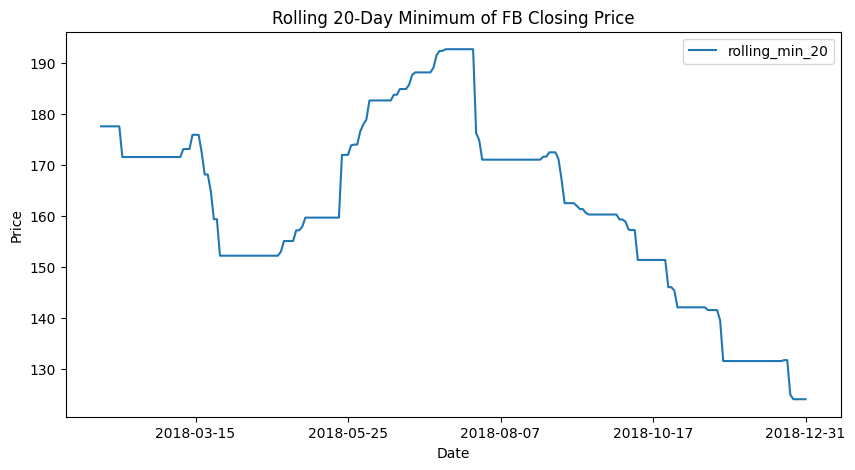

In [4]:
fb.plot(x='date', y='rolling_min_20', figsize=(10,5), title = 'Rolling 20-Day Minimum of FB Closing Price')

plt.ylabel("Price")
plt.xlabel("Date")
plt.show()

#### 2. Histogram + KDE (faang.csv):
For Facebook, calculate the daily change from open to close and create:

    ○ A histogram

    ○ A KDE (Kernel Density Estimate) plot

Display both on the same figure.

In [5]:
fb['daily_change'] = fb['close']- fb['open']

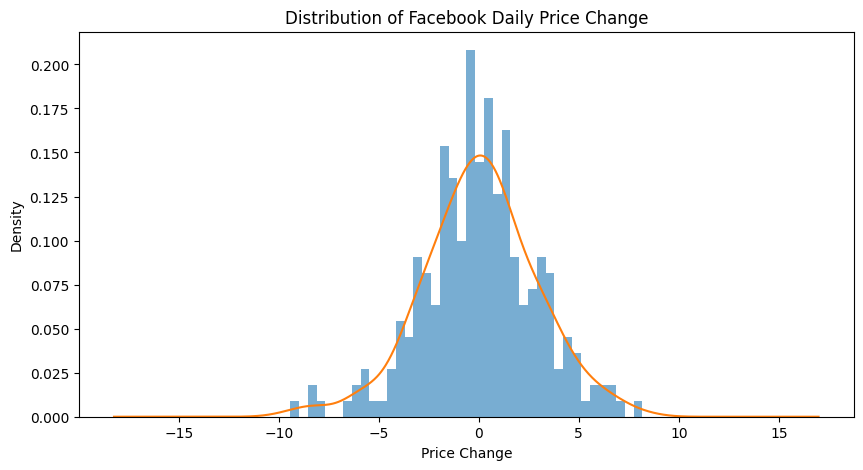

In [6]:
plt.figure(figsize=(10,5))

#Histogram
fb['daily_change'].plot(kind='hist', bins=40, density=True, alpha=0.6)

#KDE
fb['daily_change'].plot(kind='kde')

plt.title("Distribution of Facebook Daily Price Change")
plt.xlabel("Price Change")
plt.show()

#### 3. Box Plots by magType (earthquakes.csv):
Using earthquake data for Indonesia only, create box plots showing the distribution of magnitude for each magType.

In [7]:
indo_eq = earthquakes[earthquakes['parsed_place'].str.contains("Indonesia", na=False)]

<Figure size 1000x500 with 0 Axes>

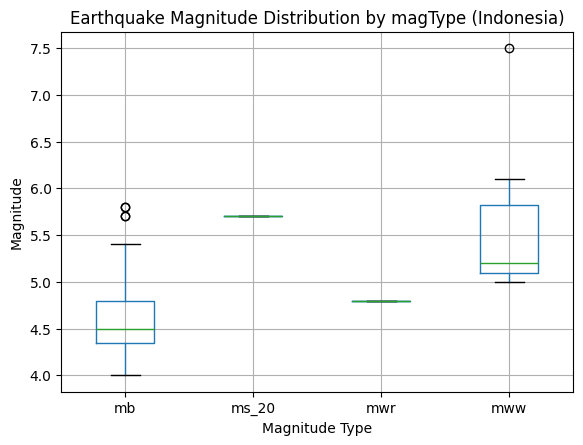

In [8]:
plt.figure(figsize=(10,5))
indo_eq.boxplot(column = 'mag', by = 'magType')

plt.title("Earthquake Magnitude Distribution by magType (Indonesia)")
plt.suptitle("")
plt.xlabel("Magnitude Type")
plt.ylabel("Magnitude")
plt.show()

#### 4. Weekly High–Low Difference (faang.csv):
For Facebook, calculate the weekly:

    ○ Maximum high

    ○ Minimum low

    ○ Then plot a single line showing the difference between them over time.

In [9]:
fb['date'] = pd.to_datetime(fb['date'])
fb_week = fb.set_index('date')

weekly_high = fb_week['high'].resample("W").max()
weekly_low = fb_week['low'].resample("W").min()

weekly_diff = weekly_high - weekly_low

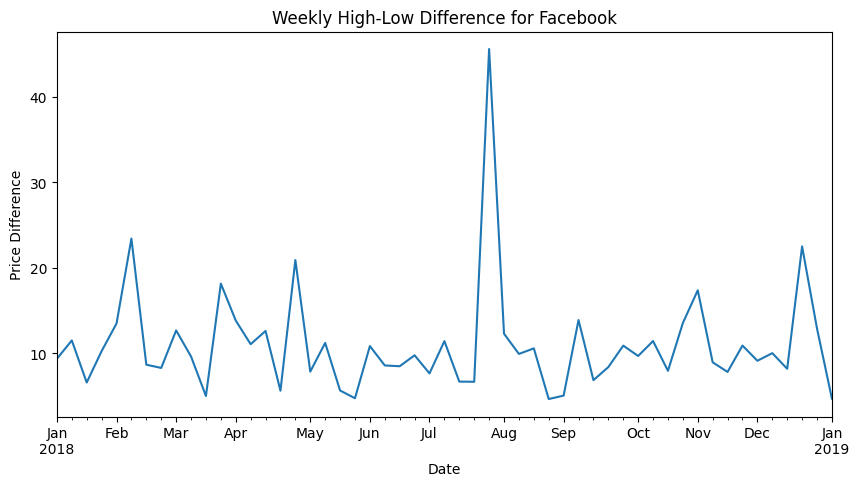

In [10]:
weekly_diff.plot(figsize=(10,5), title = 'Weekly High-Low Difference for Facebook')

plt.ylabel("Price Difference")
plt.xlabel("Date")
plt.show()

#### 5. After-Hours Trading Analysis (faang.csv):
Using matplotlib and pandas, create two side-by-side subplots analyzing the effect of after-hours trading on Facebook’s stock price:

Subplot 1:

    ○ Line plot of the daily difference between that day’s open price and the
    previous day’s close.
Subplot 2:

    ○ Bar plot showing the monthly net effect of this difference using
    resample().
    ○ Color bars green for gains and red for losses.
    ○ Modify the x-axis to show three-letter month abbreviations (e.g., Jan, Feb,
    Mar).

In [11]:
fb['prev_close'] = fb['close'].shift()
fb['after_hours_diff'] = fb['open'] - fb['close']

fb['date'] = pd.to_datetime(fb['date'])
fb_after = fb.set_index('date')

montly_effect = fb_after['after_hours_diff'].resample("ME").sum()

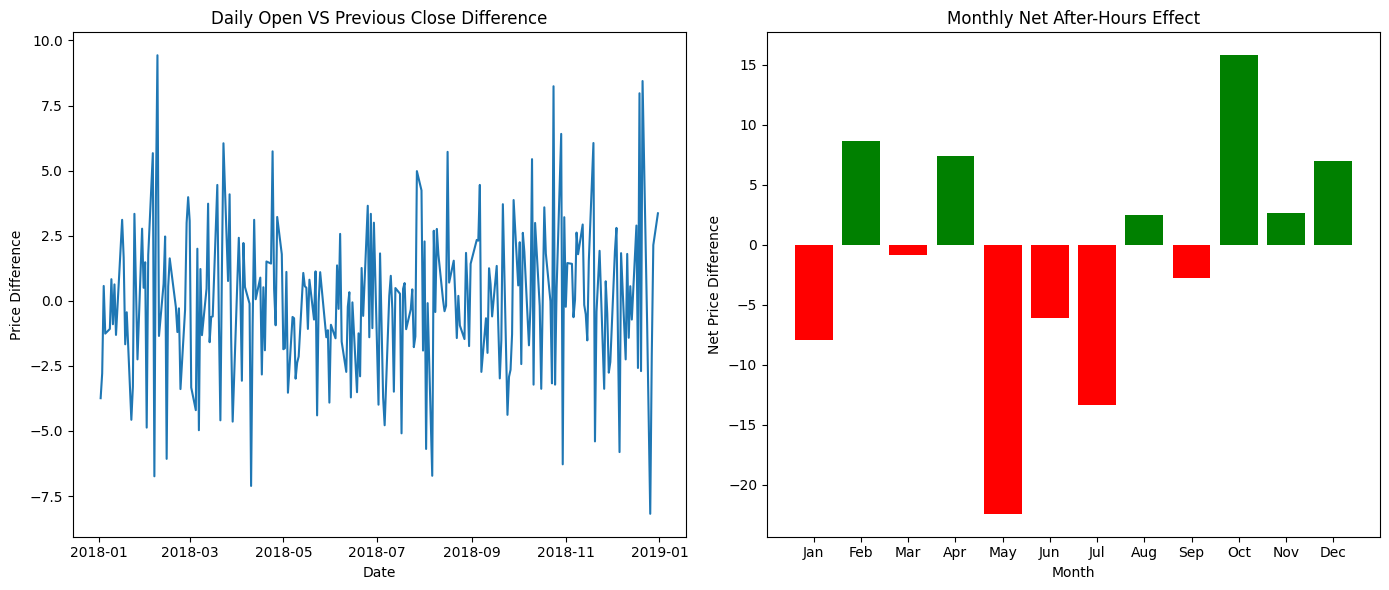

In [12]:
fig, axes = plt.subplots(1,2, figsize= (14,6))

#Subplot 1
axes[0].plot(fb_after.index, fb_after['after_hours_diff'])
axes[0].set_title("Daily Open VS Previous Close Difference")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Price Difference")

#Subplot 2
colors = ['green' if val>0 else 'red' for val in montly_effect]

axes[1].bar(montly_effect.index.strftime("%b"), montly_effect, color = colors)
axes[1].set_title("Monthly Net After-Hours Effect")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Net Price Difference")

plt.tight_layout()
plt.show()

## PART-II
Create the following visualizations using the data and the techniques covered so far.
All plots must include appropriate titles, axis labels, and legends (where needed).

#### 1. Correlation Heatmap (earthquakes.csv):
Using seaborn, create a heatmap showing the correlation between:

    ○ Earthquake magnitude

    ○ Whether a tsunami occurred

    ○ Filter the data to include only records with magType == 'mb'.

In [13]:
eq_mb = earthquakes[earthquakes['magType'] == 'mb']
corr_data = eq_mb[['mag', 'tsunami']]

corr_matrix = corr_data.corr()

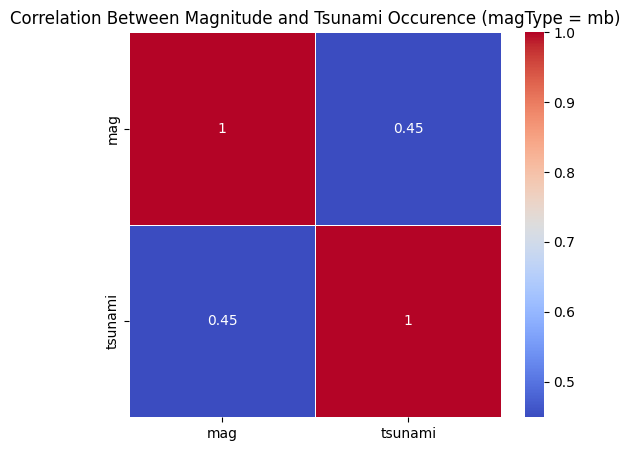

In [14]:
plt.figure(figsize=(6,5))
sns.heatmap(corr_matrix, annot = True, cmap= 'coolwarm', linewidth = 0.5)
plt.title("Correlation Between Magnitude and Tsunami Occurence (magType = mb)")
plt.show()

#### 2. Tukey Fence Box Plots (faang.csv):
For Facebook (ticker == 'FB'), create box plots (use subplots) for:

    ○ Volume traded
    ○ Closing price

In [15]:
fb = faang[faang['ticker'] == 'FB']

Q1_close = fb['close'].quantile(0.25)
Q3_close = fb['close'].quantile(0.75)
IQR_close = Q3_close - Q1_close

lower_close = Q1_close - 1.5 *IQR_close
upper_close = Q3_close +1.5 *IQR_close

Q1_vol = fb['volume'].quantile(0.25)
Q3_vol = fb['volume'].quantile(0.75)
IQR_vol = Q3_vol - Q1_vol

lower_vol = Q1_vol - 1.5 * IQR_vol
upper_vol = Q3_close + 1.5 * IQR_vol

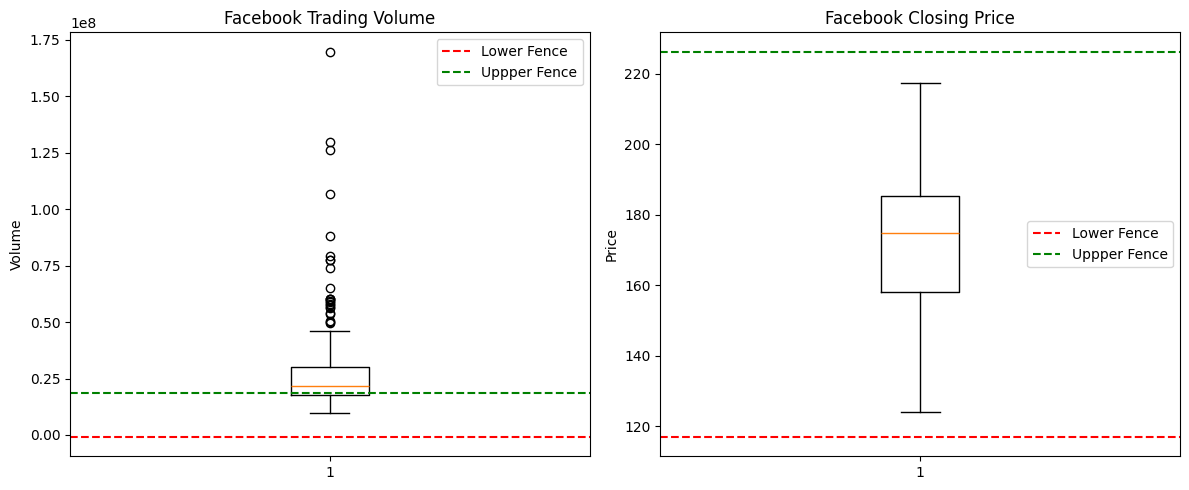

In [16]:
fig, axes = plt.subplots(1,2, figsize=(12,5))

#Volume Boxplot
axes[0].boxplot(fb['volume'], vert = True)
axes[0].axhline(lower_vol, color = 'red', linestyle = '--', label = 'Lower Fence')
axes[0].axhline(upper_vol, color = 'green', linestyle = '--', label = 'Uppper Fence')
axes[0].set_title("Facebook Trading Volume")
axes[0].set_ylabel("Volume")
axes[0].legend()


#Closing Price Boxplot
axes[1].boxplot(fb['close'], vert = True)
axes[1].axhline(lower_close, color = 'red', linestyle = '--', label = 'Lower Fence')
axes[1].axhline(upper_close, color = 'green', linestyle = '--', label = 'Uppper Fence')
axes[1].set_title("Facebook Closing Price")
axes[1].set_ylabel("Price")
axes[1].legend()

plt.tight_layout()
plt.show()

#### 3. Calculate the Tukey fence bounds using:

    ○ Lower bound = Q1 − 1.5 × IQR
    ○ Upper bound = Q3 + 1.5 × IQR
    ○ Use the quantile() method to compute Q1 and Q3.
    ○ Draw reference lines showing these bounds.

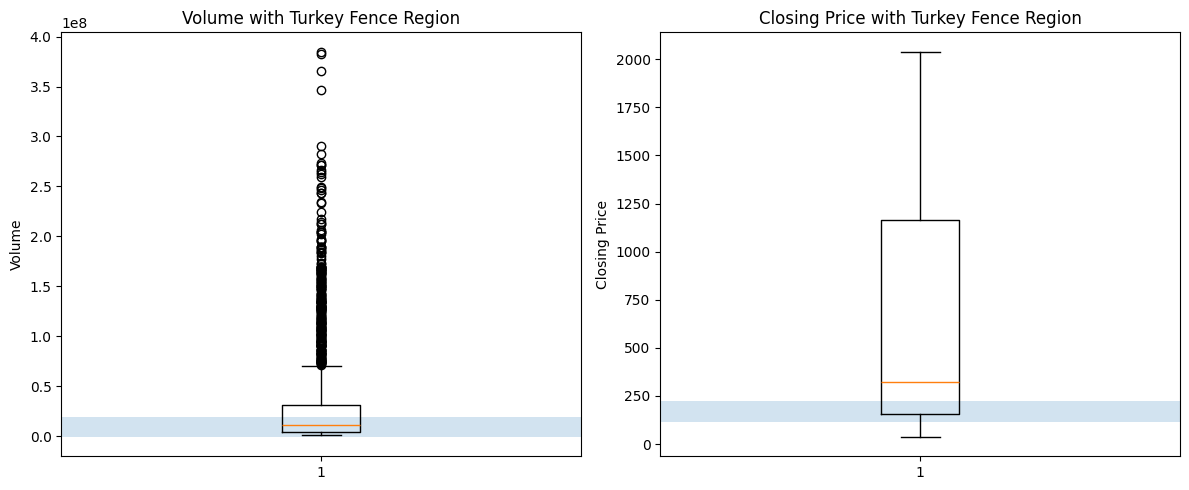

In [17]:
fig, axes = plt.subplots(1,2, figsize = (12,5))

#Volume 
axes[0].boxplot(faang['volume'])
axes[0].axhspan(lower_vol, upper_vol, alpha = 0.2)
axes[0].set_title("Volume with Turkey Fence Region")
axes[0].set_ylabel("Volume")

#Closing Price
axes[1].boxplot(faang['close'])
axes[1].axhspan(lower_close, upper_close, alpha = 0.2)
axes[1].set_title("Closing Price with Turkey Fence Region")
axes[1].set_ylabel("Closing Price")

plt.tight_layout()
plt.show()

#### 4. Highlight Price Decline (faang.csv):
Create a line plot of Facebook’s closing price.

Use axvspan() to shade the region between:

    ○ '2018-07-25'
    ○ '2018-07-31'
    ○ This highlights the major decline in price during that period.

/tmp/ipykernel_253247/2393521929.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fb['date'] = pd.to_datetime(fb['date'])


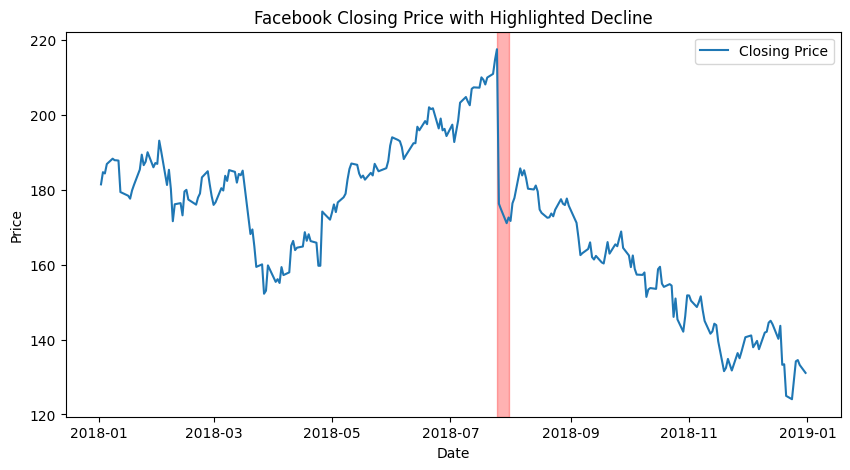

In [18]:
fb['date'] = pd.to_datetime(fb['date'])
fb = fb.sort_values('date')

plt.figure(figsize=(10,5))
plt.plot(fb['date'], fb['close'], label= 'Closing Price')

plt.axvspan(pd.to_datetime('2018-07-25'),
            pd.to_datetime('2018-07-31'),
            color = 'red',
            alpha = 0.3
            )


plt.title("Facebook Closing Price with Highlighted Decline")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()

plt.show()

#### 5. Event Annotations (faang.csv):
On a line plot of Facebook’s closing price, annotate the following events:

    ○ Disappointing user growth announced after close on July 25, 2018
    ○ Cambridge Analytica story breaks on March 19, 2018
    ○ FTC launches investigation on March 20, 2018
    ○ Use appropriate annotation positioning to keep the plot readable.

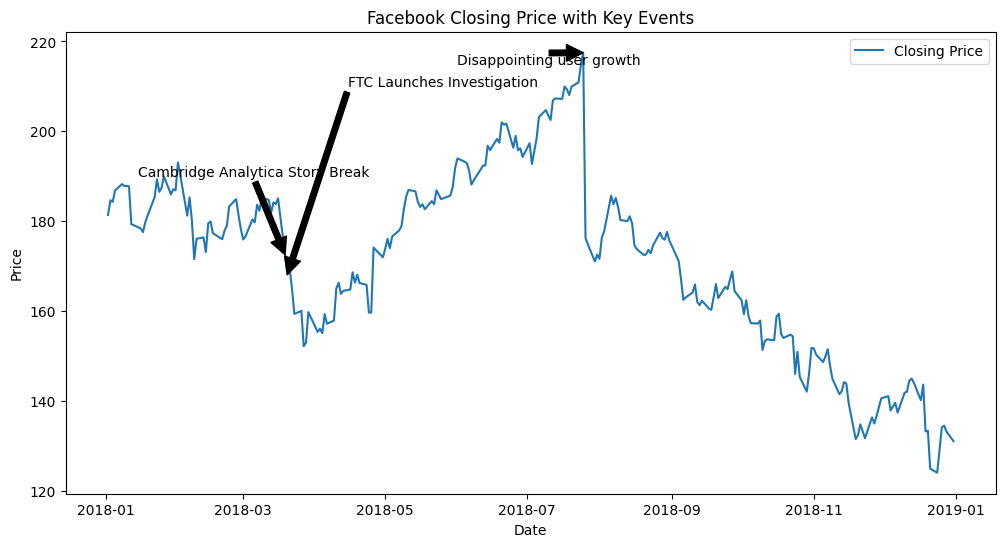

In [19]:
fb['date'] = pd.to_datetime(fb['date'])
fb = fb.sort_values('date')

plt.figure(figsize=(12,6))
plt.plot(fb['date'], fb['close'], label = 'Closing Price')

#Event 2
plt.annotate(
    "Cambridge Analytica Story Break",
    xy = (pd.to_datetime('2018-03-19'), fb.loc[fb['date'] == pd.to_datetime('2018-03-19'), 'close'].values[0]),
    xytext=(pd.to_datetime('2018-01-15'), 190)   ,
    arrowprops=dict(facecolor = 'black')
)

#Event 3
plt.annotate(
    "FTC Launches Investigation",
    xy = (pd.to_datetime('2018-03-20'), fb.loc[fb['date'] == pd.to_datetime('2018-03-20'), 'close'].values[0]),
    xytext=(pd.to_datetime('2018-04-15'), 210)   ,
    arrowprops=dict(facecolor = 'black')
)


#Event 1
plt.annotate(
    "Disappointing user growth",
    xy = (pd.to_datetime('2018-07-25'), fb.loc[fb['date'] == pd.to_datetime('2018-07-25'), 'close'].values[0]),
    xytext=(pd.to_datetime('2018-06-01'), 215)   ,
    arrowprops=dict(facecolor = 'black')
)

plt.title("Facebook Closing Price with Key Events")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()

plt.show()


#### 6. Colormap Customization:
Modify the reg_resid_plots() function so that it:

    ○ Uses a matplotlib colormap instead of cycling between two colors
    ○ Applies a qualitative colormap (or a custom-defined one) appropriate for categorical comparison

In [20]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

def reg_resid_plots(data, x_col, y_col, category_col):
    categories = data[category_col].unique()
    cmap = cm.get_cmap('tab10', len(categories))
    
    plt.figure(figsize=(8, 6))
    
    for i, cat in enumerate(categories):
        subset = data[data[category_col] == cat]
        if subset.empty:
            print(f"No data for category: {cat}")
            continue
        plt.scatter(subset[x_col], subset[y_col], color=cmap(i), label=cat)
    
    plt.title("Regression Residual Plot with Colormap")
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.legend()
    plt.show()  

/tmp/ipykernel_253247/681875039.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab10', len(categories))


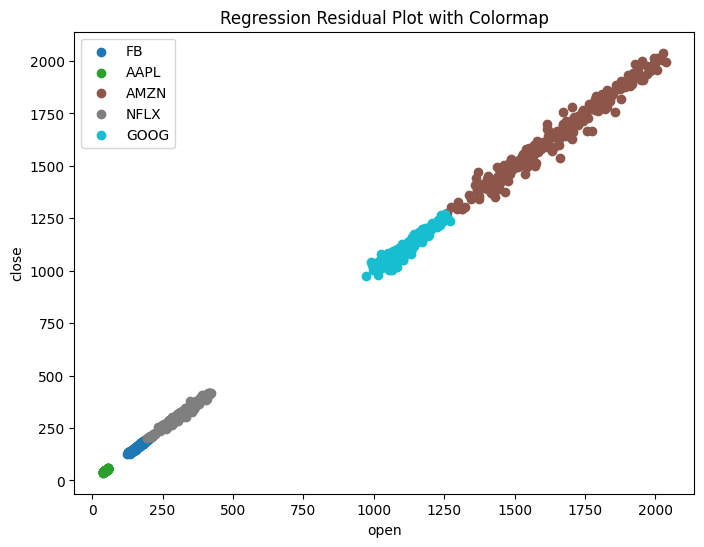

In [21]:
#func call
reg_resid_plots(faang, 'open', 'close', 'ticker')
